In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mglearn

In [2]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

In [3]:
print("Keys of iris_dataset: \n", iris_dataset.keys())

Keys of iris_dataset: 
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
print("Target :",iris_dataset['target'])

Target : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [5]:
iris_dataset

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [6]:
print("Target names :",iris_dataset['target_names'])

Target names : ['setosa' 'versicolor' 'virginica']


In [7]:
print("Feature names :",iris_dataset['feature_names'])

Feature names : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [8]:
print(type(iris_dataset['data']))

<class 'numpy.ndarray'>


In [9]:
print("Shape :", iris_dataset['data'].shape)

Shape : (150, 4)


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=0)

In [12]:
print(X_train.shape)

(112, 4)


In [13]:
print(X_test.shape)

(38, 4)


In [14]:
iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.feature_names)

In [15]:
# create a scatter matrix from the dataframe, color by y_train
# figsize : sets the size of the entire figure to 15x15 inches.
# marker='o': Uses circle markers for the scatter plots.
# hist_kwds={'bins': 20}: Specifies that histograms in the diagonal plots should have 20 bins.
# s=60: Sets the size of the markers to 60 points^2.
# alpha=.8: Sets the transparency of the markers to 80%.
# cmap=mglearn.cm3: Uses a colormap from the mglearn library for coloring the points.

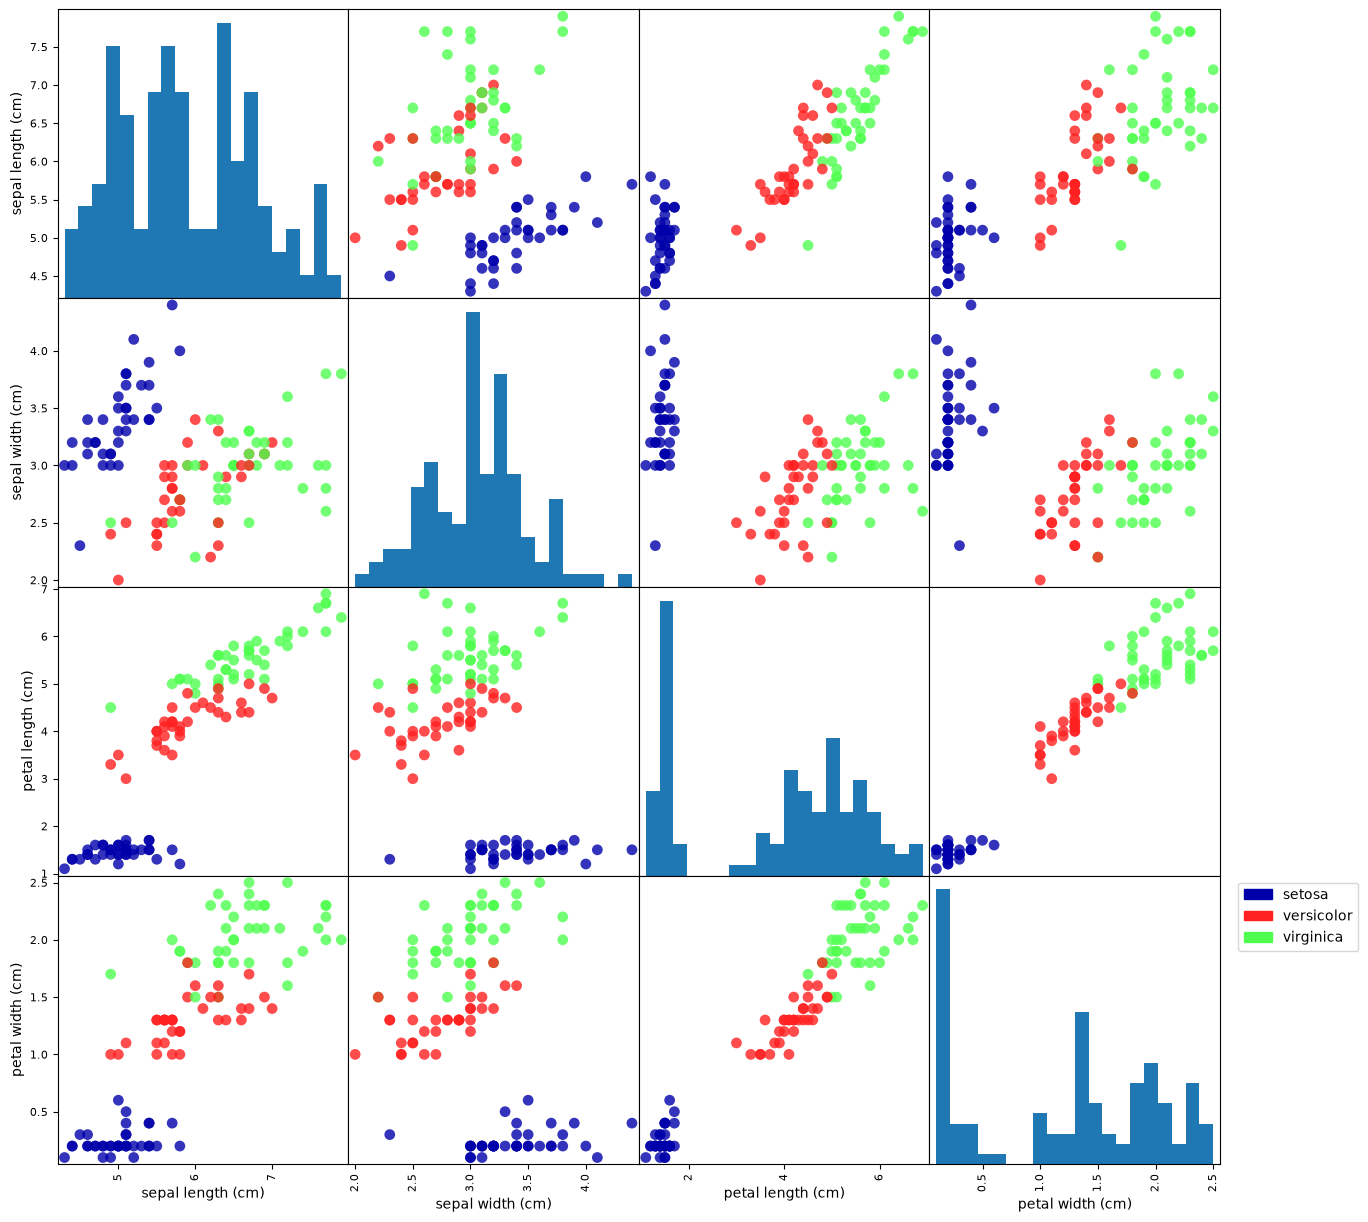

In [16]:
#create scatter plot
pd.plotting.scatter_matrix(iris_dataframe, c=y_train, figsize=(15, 15),
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=.8, cmap=mglearn.cm3)
#add legend
class_names = ['setosa', 'versicolor', 'virginica']
#color
classes = np.unique(y_train)
colors = [mglearn.cm3(i / len(classes)) for i in range(len(classes))]
#create the legend handles
import matplotlib.patches as mpatches
handles = [mpatches.Patch(color=colors[i], label=class_names[classes[i]]) for i in range(len(classes))]
#add legend to the plot
plt.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.5, 1))
plt.show()

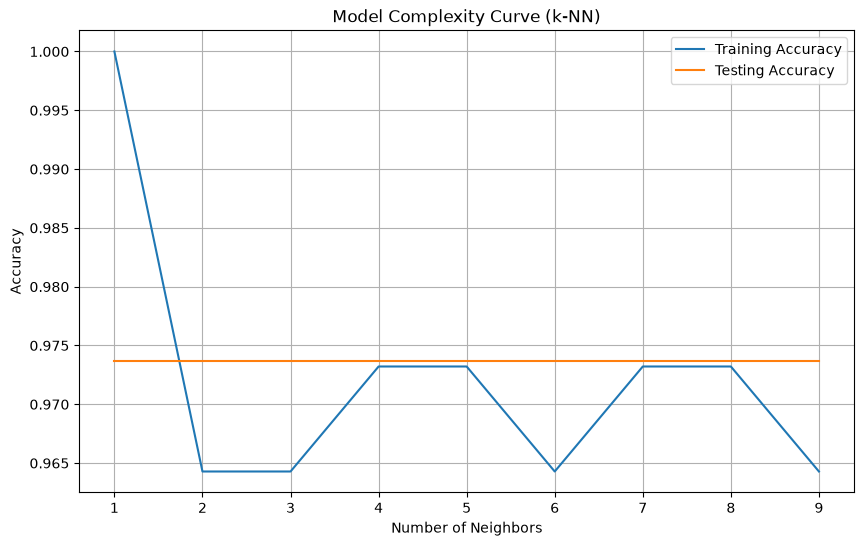

In [17]:
#determine the optimal value of k
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
 
train_accuracies = []
test_accuracies = []
# try n_neighbors from 1 to 9
neighbors = range(1, 10)
for n in neighbors:
    # build the model
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))
 
plt.figure(figsize=(10, 6))
plt.plot(neighbors, train_accuracies, label='Training Accuracy')
plt.plot(neighbors, test_accuracies, label='Testing Accuracy')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('Model Complexity Curve (k-NN)')
plt.legend()
plt.grid(True)
plt.show()


In [18]:
knn = KNeighborsClassifier(n_neighbors=3)

In [19]:
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [20]:
KNeighborsClassifier(n_neighbors=3)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [21]:
#prediction

In [22]:
prediction = knn.predict(X_test)
print(prediction)
print(iris_dataset['target_names'][prediction])

[2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
['virginica' 'versicolor' 'setosa' 'virginica' 'setosa' 'virginica'
 'setosa' 'versicolor' 'versicolor' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'versicolor' 'versicolor' 'setosa' 'versicolor' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'setosa' 'setosa' 'virginica'
 'setosa' 'setosa' 'versicolor' 'versicolor' 'setosa' 'virginica'
 'versicolor' 'setosa' 'virginica' 'virginica' 'versicolor' 'setosa'
 'virginica']


In [23]:
print("Train set score: {:.2f}".format(knn.score(X_train, y_train)))

Train set score: 0.96


In [24]:
print("Test set score: {:.2f}".format(knn.score(X_test, y_test)))

Test set score: 0.97


In [25]:
y_pred = knn.predict(X_test)
print("Test set score: {:.2f}".format(np.mean(y_pred == y_test)))

Test set score: 0.97


## Prediction using New Data

In [26]:
import numpy as np
X_new = np.array([[40, 80, 70, 30]])
print("X_new.shape:", X_new.shape)

X_new.shape: (1, 4)


In [27]:
prediction = knn.predict(X_new)
print("Prediction:", prediction)
print("Predicted target name:",
iris_dataset['target_names'][prediction])

Prediction: [2]
Predicted target name: ['virginica']


In [28]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print("cancer.keys(): \n{}".format(cancer.keys()))

cancer.keys(): 
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [29]:
print(type(cancer))

<class 'sklearn.utils._bunch.Bunch'>

NOTE:
The cancer variable is a Bunch object, which behaves like a dictionary — you can access its contents using dot notation or keys.
If you want to inspect the data types of specific parts of the dataset (like the features or target), try:
print(type(cancer.data))       # Usually a NumPy array
print(cancer.data.dtype)       # Data type of the features
print(type(cancer.target))     # Also a NumPy array
print(cancer.target.dtype)     # Data type of the target

In [30]:
print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [31]:
print("Shape of cancer data{}".format(cancer.data.shape))

Shape of cancer data(569, 30)

In [32]:
print(cancer.feature_names) # predictor columns

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [33]:
print(cancer.target)
print(cancer.target_names) # target classes

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

In [34]:
#Of these 569 data points, 212 are labeled as malignant and 357 as benign
#pairs each class name with its corresponding count.
#cancer.target_names        - This is an array of class names: ['malignant', 'benign']
#np.bincount(cancer.target) - counts how many times each class label appears 
#zip(cancer.target_names, np.bincount(cancer.target))
#  - Pairs each class name with its corresponding count.  Example: [('malignant', 212), ('benign', 357)]
#{n: v for n, v in zip(...)} - Builds a dictionary from the zipped pairs, and prints the dictionary in a formatted string.
 
print("Sample counts per class:\n{}".
      format({n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))}))

Sample counts per class:
{np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


## CONVERT cancer dataset to a dataframe

In [35]:
# Create a DataFrame with feature data

df = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
 
# Add the target column

df['target'] = cancer.target
 
# Display the first few rows

print(df.head())
 

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [36]:
#retrieve 2nd row of training data - it will be used for prediction testing later...
#Try the different format below...
 
row_train_tuple = df.iloc[1]
row_train_tuple

mean radius                  20.570000
mean texture                 17.770000
mean perimeter              132.900000
mean area                  1326.000000
mean smoothness               0.084740
mean compactness              0.078640
mean concavity                0.086900
mean concave points           0.070170
mean symmetry                 0.181200
mean fractal dimension        0.056670
radius error                  0.543500
texture error                 0.733900
perimeter error               3.398000
area error                   74.080000
smoothness error              0.005225
compactness error             0.013080
concavity error               0.018600
concave points error          0.013400
symmetry error                0.013890
fractal dimension error       0.003532
worst radius                 24.990000
worst texture                23.410000
worst perimeter             158.800000
worst area                 1956.000000
worst smoothness              0.123800
worst compactness        

In [37]:
#row_train_tuple = pd.DataFrame(df.iloc[1,0:30])
#row_train_tuple
 
row_train_tuple = pd.DataFrame(df.iloc[1,0:30]).T     #T = transpose
row_train_tuple

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.186,0.275,0.08902


In [38]:
#split data
 
from sklearn.model_selection import train_test_split
 
# Separate predictors and target
X = df.drop(columns='target')  # Features
y = df['target']               # Target
 
#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=66)
 
#control the train/test split by adding the test_size or train_size parameter : train_size = 0.80

In [39]:
print(X_train.shape, y_train.shape)

(426, 30) (426,)


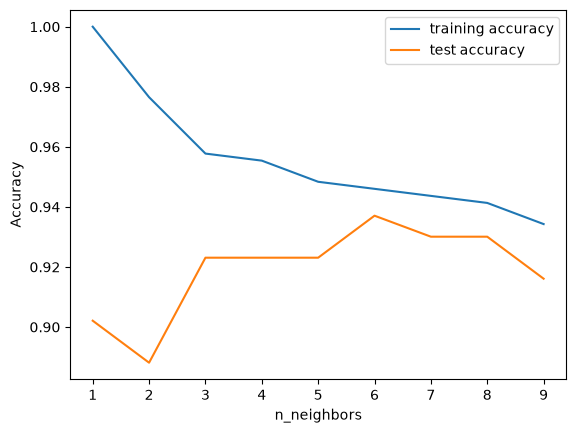

In [40]:
training_accuracy = []
test_accuracy = []
 
# try n_neighbors from 1 to 9
neighbors_settings = range(1, 10)
 
from sklearn.neighbors import KNeighborsClassifier
for n_neighbors in neighbors_settings:                    #run the model using different k values
   # build the model
   knn = KNeighborsClassifier(n_neighbors=n_neighbors)    #model
   knn.fit(X_train, y_train)                              #train the model
   # record training set accuracy
   training_accuracy.append(knn.score(X_train, y_train))
   # record generalization accuracy
   test_accuracy.append(knn.score(X_test, y_test))
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [41]:
# BUILD THE KNN MODEL with k value based on the complexity curve
 
knn = KNeighborsClassifier(n_neighbors=6)     #build the model
knn.fit(X_train, y_train)                     #train the model

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [42]:
print("Train test predictions: {}".format(knn.predict(X_train)))
print("Train test accuracy: {}".format(knn.score(X_train,y_train)))
print("Train test accuracy: {:.2f}".format(knn.score(X_train,y_train)))

Train test predictions: [1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 0 1 1 1 0 1 1 1
 0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 1 1 0 0 0 1 1 1
 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0
 0 1 1 1 1 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1
 0 1 1 0 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 1 1
 0 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1
 0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 0 0 1 0 1 0 1 1 1 0 1
 1 1 0 1 0 1 1 0 0 0 1 1 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 1 1 1 1 0 1 0 1 1
 0 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1
 0 1 1 1 1 0 0 0 1 1 1 0 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1
 0 0 1 1 1 1 0 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 1
 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0 1 0]
Train test accuracy: 0.9460093896713615
Train test accuracy: 0.95


In [43]:
print("Test set predictions: {}".format(knn.predict(X_test)))
print("Test set accuracy: {}".format(knn.score(X_test, y_test)))
print("Test set accuracy: {:.2f}".format(knn.score(X_test, y_test)))

Test set predictions: [1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 0 0 1 0 0 1 0
 1 1 0 1 0 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 0 1 0
 1 0 1 1 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1
 0 0 0 1 1 1 0 0 1 1 0 0 0 0 0 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1]
Test set accuracy: 0.9370629370629371
Test set accuracy: 0.94


In [147]:
raw_data = """
mean radius                  20.570000
mean texture                 17.770000
mean perimeter              132.900000
mean area                  1326.000000
mean smoothness               0.084740
mean compactness              0.078640
mean concavity                0.086900
mean concave points           0.070170
mean symmetry                 0.181200
mean fractal dimension        0.056670
radius error                  0.543500
texture error                 0.733900
perimeter error               3.398000
area error                   74.080000
smoothness error              0.005225
compactness error             0.013080
concavity error               0.018600
concave points error          0.013400
symmetry error                0.013890
fractal dimension error       0.003532
worst radius                 24.990000
worst texture                23.410000
worst perimeter             158.800000
worst area                 1956.000000
worst smoothness              0.123800
worst compactness             0.186600
worst concavity               0.241600
worst concave points          0.186000
worst symmetry                0.275000
worst fractal dimension       0.089020
"""

In [149]:
# Convert to dictionary
data_dict = dict(line.rsplit(maxsplit=1) for line in raw_data.strip().split('\n'))
data_dict = {k: float(v) for k, v in data_dict.items()}

In [150]:
# Create DataFrame
new_data = pd.DataFrame([data_dict])
print(new_data)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        20.57         17.77           132.9     1326.0          0.08474   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.07864          0.0869              0.07017         0.1812   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0                 0.05667  ...         24.99          23.41            158.8   

   worst area  worst smoothness  worst compactness  worst concavity  \
0      1956.0            0.1238             0.1866           0.2416   

   worst concave points  worst symmetry  worst fractal dimension  
0                 0.186           0.275                  0.08902  

[1 rows x 30 columns]


In [151]:
# Make a prediction using the New Data
prediction = knn.predict(new_data)
print("Prediction: {}".format(prediction))
target_names = ['malignant', 'benign']
predicted_label = target_names[prediction[0]]
print("Predicted target name:", predicted_label)

Prediction: [0]
Predicted target name: malignant
